In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка дата сета
df = pd.read_csv('/content/loan_data (1).csv')

In [4]:
print(f"Размер данных: {df.shape}")
print("\nПервые 5 строк")
display(df.head())

print("\nИнформация о типах данных и пропусках")
df.info()

print("\nСтатистика по числовым признакам")
display(df.describe())

Размер данных: (45000, 14)

Первые 5 строк


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1



Информация о типах данных и пропусках
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64 

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


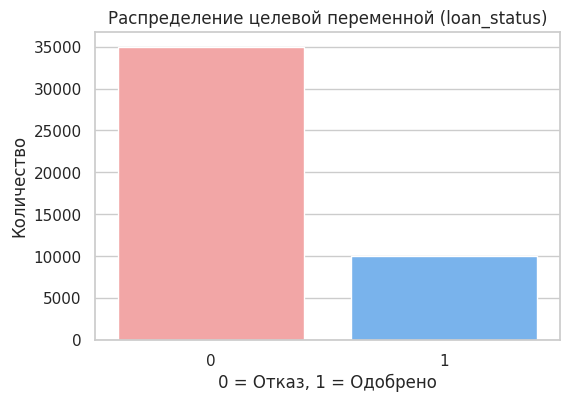


Процент одобрений: 22.22%


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df, palette=['#ff9999', '#66b3ff'])
plt.title('Распределение целевой переменной (loan_status)')
plt.xlabel('0 = Отказ, 1 = Одобрено')
plt.ylabel('Количество')
plt.show()

print(f"\nПроцент одобрений: {df['loan_status'].mean() * 100:.2f}%")

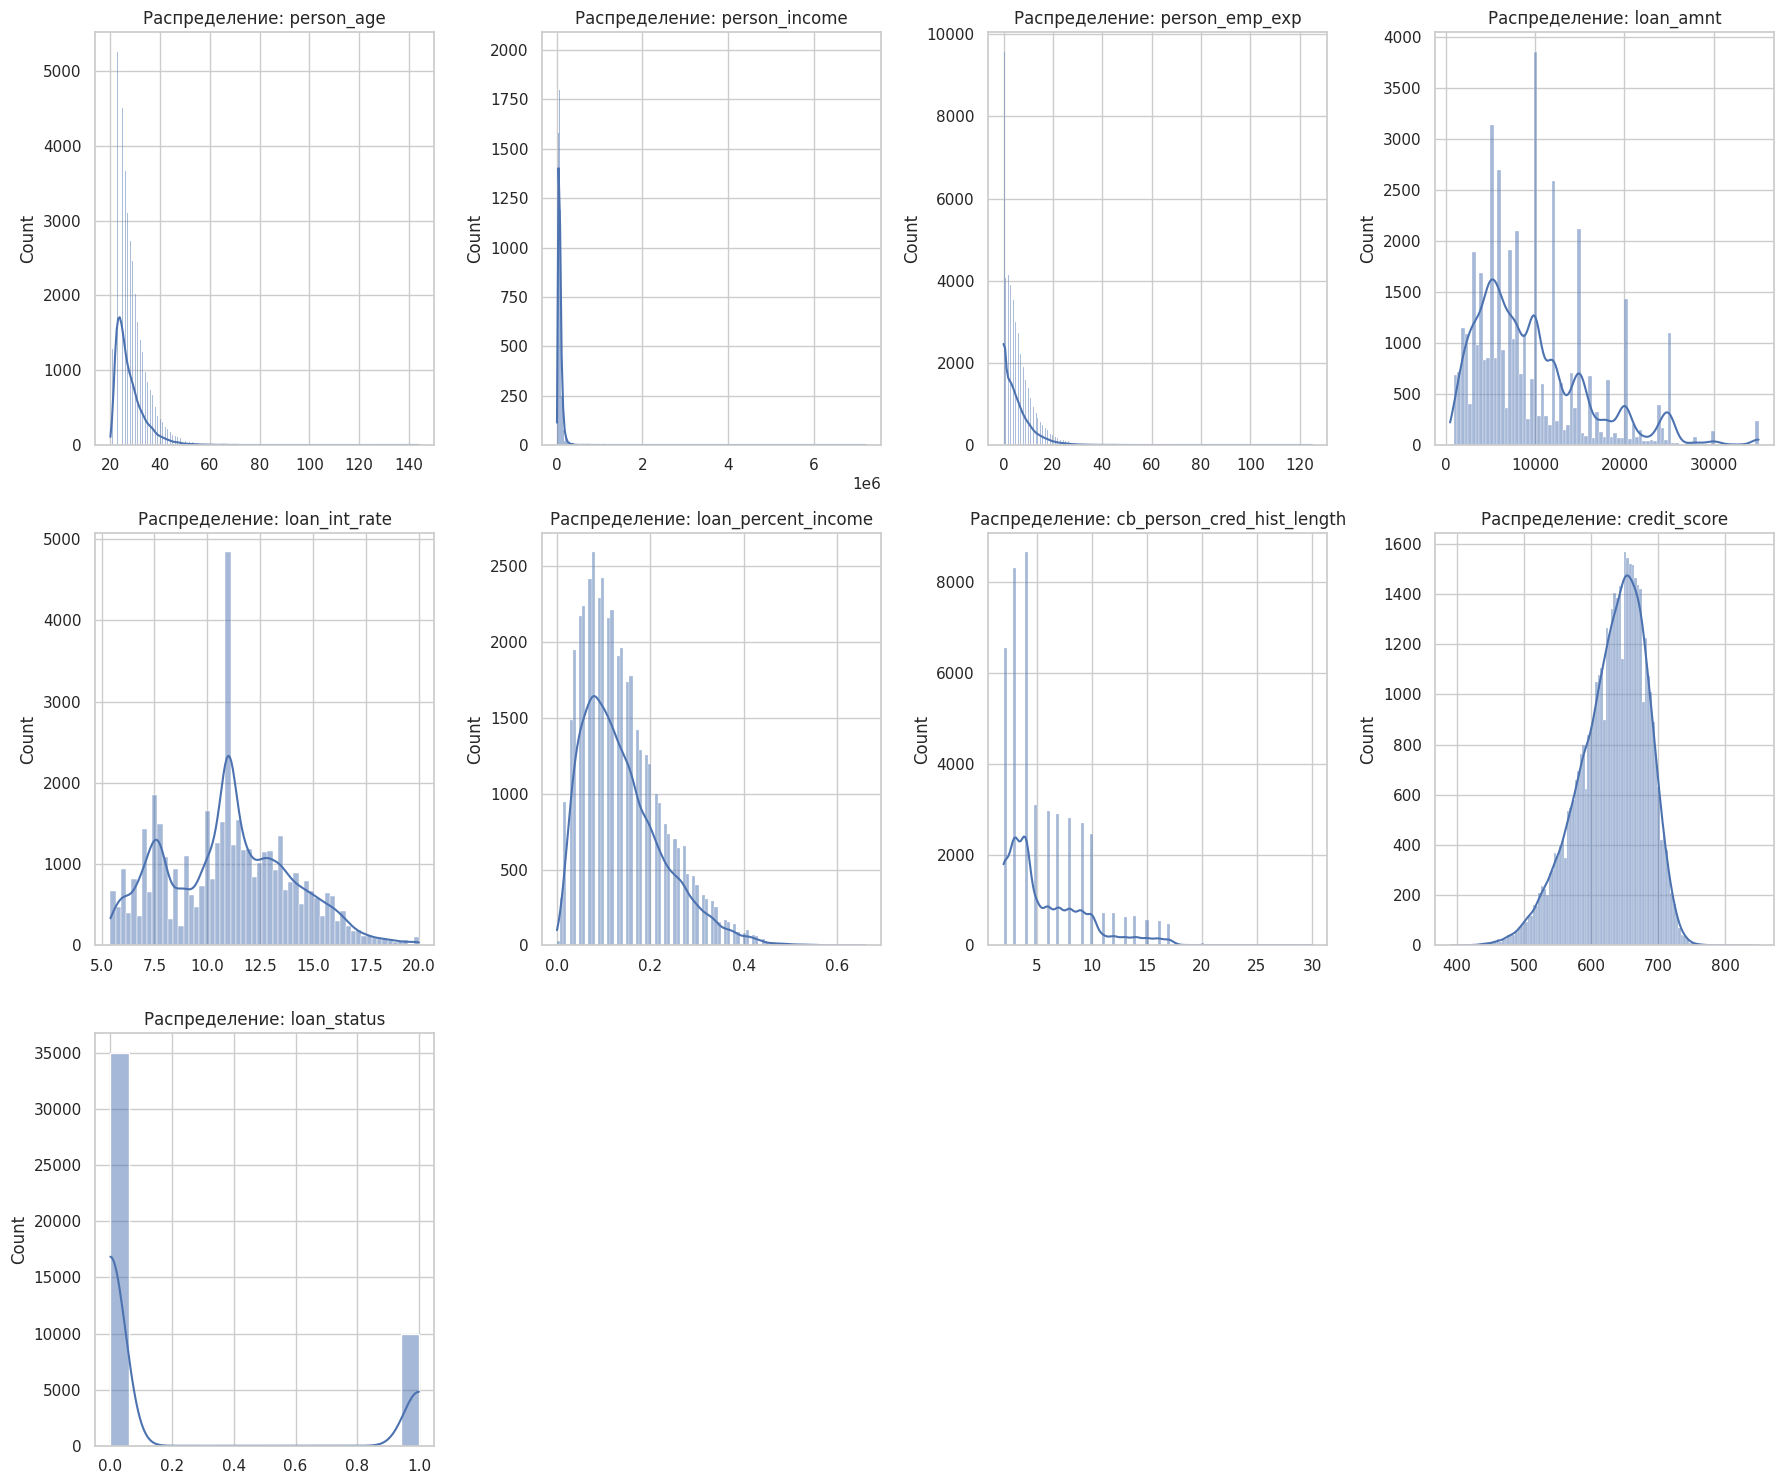

In [6]:
# Выбираем только числовые колонки
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(18, 15))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Распределение: {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

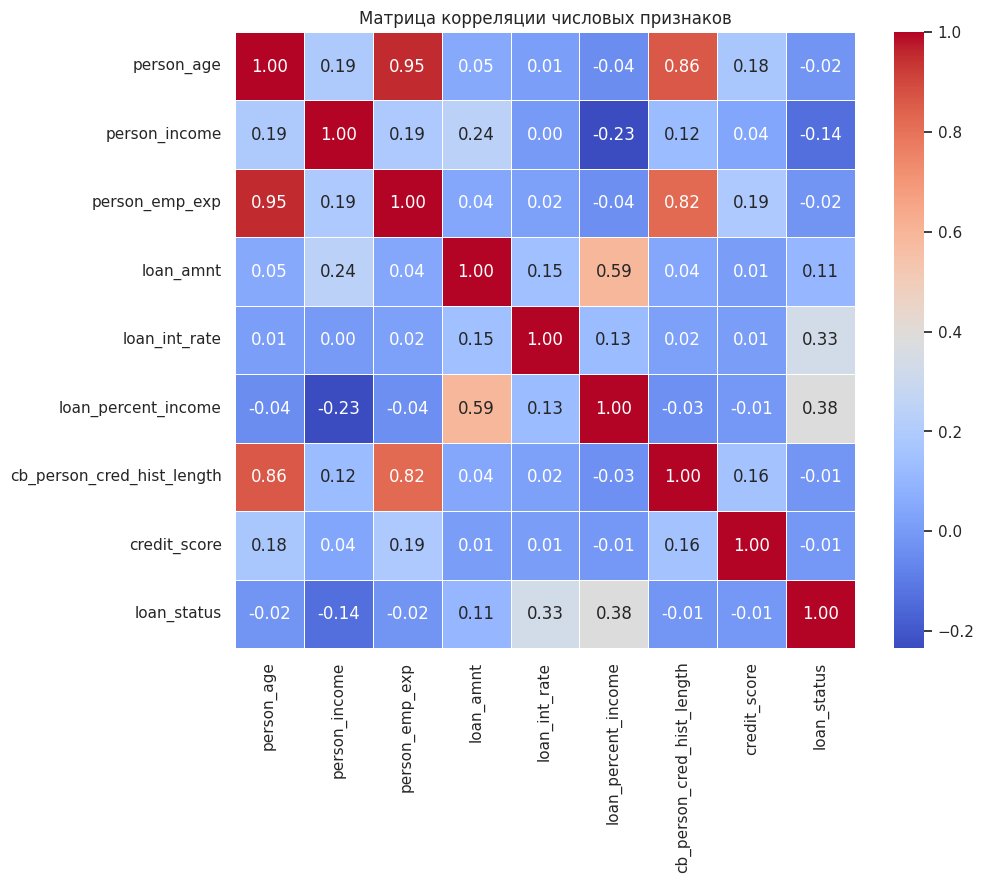

In [7]:
plt.figure(figsize=(10, 8))
# Вычисляем корреляцию Пирсона для всех числовых колонок
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Матрица корреляции числовых признаков')
plt.show()

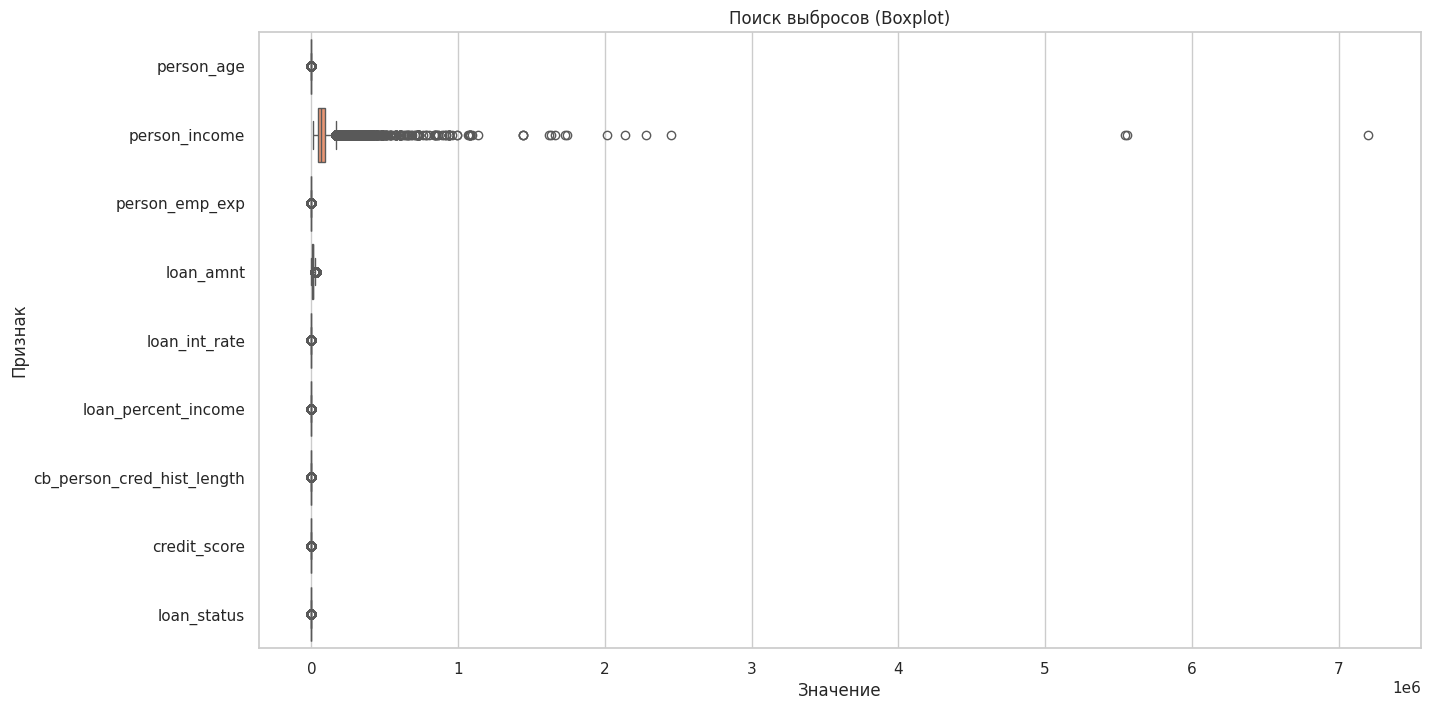

In [8]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numeric_cols], orient="h", palette="Set2")
plt.title('Поиск выбросов (Boxplot)')
plt.xlabel('Значение')
plt.ylabel('Признак')
plt.show()

In [9]:
# В этом датасете часто бывают ошибки в возрасте (слишком старые)
# и длине кредитной истории
print("--- Подозрительные данные ---")
print(f"Люди старше 90 лет: {df[df['person_age'] > 90].shape[0]}")
print(f"Отрицательная кредитная история: {df[df['cb_person_cred_hist_length'] < 0].shape[0]}")
print(f"Нулевой кредитный рейтинг: {df[df['credit_score'] == 0].shape[0]}")

--- Подозрительные данные ---
Люди старше 90 лет: 8
Отрицательная кредитная история: 0
Нулевой кредитный рейтинг: 0


In [10]:
import pandas as pd
import numpy as np

# 1. Копия датасета (чтобы не ломать исходный df)
df_clean = df.copy()

# 2. Удаление аномалий (Age > 80 лет)
print(f"До удаления: {df_clean.shape}")
df_clean = df_clean[df_clean['person_age'] <= 80]
print(f"После удаления старых людей: {df_clean.shape}")

# 3. Логическая проверка (Возраст - Опыт работы > 16 лет)
# Человек не может работать, если ему меньше 16 лет
# Если person_age - person_emp_exp < 16, значит данные кривые
df_clean = df_clean[df_clean['person_age'] - df_clean['person_emp_exp'] >= 16]
print(f"После проверки логики: {df_clean.shape}")

# 4. Отбор признаков(Feature Selection)
# Удаляем person_age из-за корреляции 0.95 с person_emp_exp
# Удаляем loan_percent_income? Нет, он важен (корреляция 0.38 с целевой).
# Удаляем person_gender? Можно оставить, но часто в ML кредитовании его убирают (этика).
# Для лабы оставим, но можно удалить.

drop_cols = ['person_age'] # Удаляем возраст
df_clean = df_clean.drop(columns=drop_cols)

# 5. Логарифмирование (Log Transform) для сглаживания "хвостов"
# Доход и сумма кредита имеют длинный хвост вправо
df_clean['person_income_log'] = np.log1p(df_clean['person_income'])
df_clean['loan_amnt_log'] = np.log1p(df_clean['loan_amnt'])

# Теперь можно удалить старые колонки и оставить логарифмированные
df_clean = df_clean.drop(columns=['person_income', 'loan_amnt'])

# 6. Подготовка X и y
y = df_clean['loan_status']
X = df_clean.drop(columns=['loan_status'])

# 7. Разделение на TRAIN / TEST
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # Сохраняем пропорции 22/78 в обоих наборах
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Сохраняем готовые данные, чтобы потом передать в PyCharm
# Если нужно: df_clean.to_csv('data_clean.csv', index=False)

До удаления: (45000, 14)
После удаления старых людей: (44991, 14)
После проверки логики: (44991, 14)
X_train shape: (35992, 12)
X_test shape: (8999, 12)


--- Обучение: Logistic Regression ---
ROC-AUC Score: 0.9566
--- Обучение: Random Forest ---
ROC-AUC Score: 0.9736
--- Обучение: Gradient Boosting ---
ROC-AUC Score: 0.9711

Classification Report:
              precision    recall  f1-score   support

     Refused       0.93      0.97      0.95      6999
    Approved       0.88      0.76      0.82      2000

    accuracy                           0.92      8999
   macro avg       0.91      0.87      0.88      8999
weighted avg       0.92      0.92      0.92      8999

Итоговый рейтинг (ROC-AUC):
1. Random Forest: 0.9736
2. Gradient Boosting: 0.9711
3. Logistic Regression: 0.9566


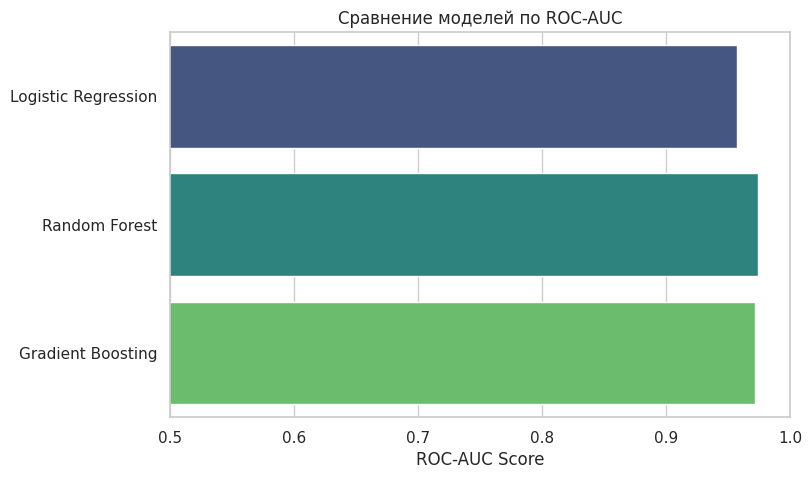


 Лучшая модель (Random Forest) сохранена в 'best_mortgage_model.pkl'


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Определяем категориальные и числовые признаки
# (важно для предобработки внутри Pipeline)
numeric_features = ['person_emp_exp', 'loan_int_rate', 'loan_percent_income',
                    'cb_person_cred_hist_length', 'credit_score',
                    'person_income_log', 'loan_amnt_log']

categorical_features = ['person_gender', 'person_education', 'person_home_ownership',
                        'loan_intent', 'previous_loan_defaults_on_file']

# 2. Создаем препроцессинг (ColumnTransformer)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Трансформер для чисел:Scaler (пропусков нет, но на всякий случай импутер)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Трансформер для категорий: OneHotEncoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 3. Инициализируем модели
# class_weight='balanced' используем из-за дисбаланса классов
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}
results = {}

for name, model in models.items():
    print(f"--- Обучение: {name} ---")

    # Создаем полный пайплайн: препроцессинг + модель
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Обучаем
    clf.fit(X_train, y_train)

    # Предсказываем вероятности (для ROC-AUC нужен класс 1)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    # Считаем ROC-AUC
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = roc_auc

    print(f"ROC-AUC Score: {roc_auc:.4f}")

    # Выводим метрики для лучшей модели
    if name == 'Gradient Boosting': # Обычно GB лучший
        y_pred = clf.predict(X_test)
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Refused', 'Approved']))

# 4. Сравнение моделей
print("Итоговый рейтинг (ROC-AUC):")
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
for rank, (name, score) in enumerate(sorted_results, 1):
    print(f"{rank}. {name}: {score:.4f}")

# 5. График ROC-AUC
plt.figure(figsize=(8, 5))
sns.barplot(x=list(results.values()), y=list(results.keys()), palette='viridis')
plt.title('Сравнение моделей по ROC-AUC')
plt.xlabel('ROC-AUC Score')
plt.xlim([0.5, 1.0]) # От 0.5 (случайность) до 1.0 (идеал)
plt.show()

# 6. Сохраняем лучшую модель
best_model_name = sorted_results[0][0]
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models[best_model_name])
])
# Переобучаем лучшую модель на всем трейне (она уже обучена выше, но на всякий случай)
best_model.fit(X_train, y_train)

import joblib
joblib.dump(best_model, 'best_mortgage_model.pkl')
print(f"\n Лучшая модель ({best_model_name}) сохранена в 'best_mortgage_model.pkl'")